# Generación con Modelos Probabilísticos

In [2]:
'''Main'''
import numpy as np
import pandas as pd
import os, time, re
import pickle, gzip, datetime

'''Data Viz'''
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import Grid

%matplotlib inline

'''Data Prep and Model Evaluation'''
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score, mean_squared_error

'''Algoritmo'''
import lightgbm as lgb

'''TensorFlow and Keras'''
import tensorflow as tf
import keras
from keras import backend as K
from keras.models import Sequential, Model
from keras.layers import Activation, Dense, Dropout
from keras.layers import BatchNormalization, Input, Lambda
from keras.layers import Embedding, Flatten, dot
from keras import regularizers
from tensorflow.keras.losses import mse, binary_crossentropy

In [3]:
# Cargar la base de datos
(x_medio, y_medio), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = np.reshape(x_medio[:50000],(50000,784))/255
y_train = y_medio[:50000]

X_val = np.reshape(x_medio[50000:],(10000,784))/255
y_val = y_medio[50000:]

X_test = np.reshape(x_test,(10000,784))/255

In [4]:
# Verificar el tamaño del dataset
print("Shape of X_train: ", X_train.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of X_validation: ", X_val.shape)
print("Shape of y_validation: ", y_val.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (50000, 784)
Shape of y_train:  (50000,)
Shape of X_validation:  (10000, 784)
Shape of y_validation:  (10000,)
Shape of X_test:  (10000, 784)
Shape of y_test:  (10000,)


In [5]:
# Crear un frame de Pandas
train_index = range(0,len(X_train))
validation_index = range(len(X_train),len(X_train)+len(X_val))
test_index = range(len(X_train)+len(X_val), \
                   len(X_train)+len(X_val)+len(X_test))

X_train = pd.DataFrame(data=X_train,index=train_index)
y_train = pd.Series(data=y_train,index=train_index)

X_val = pd.DataFrame(data=X_val,index=validation_index)
y_val = pd.Series(data=y_val,index=validation_index)

X_test = pd.DataFrame(data=X_test,index=test_index)
y_test = pd.Series(data=y_test,index=test_index)

In [ ]:
# Describe el set de entrenamiento
# X_train.describe()                # No tan necesario para MNIST

In [6]:
# Mostrar las etiquetas
y_train.head()

0    5
1    0
2    4
3    1
4    9
dtype: uint8

In [7]:
def view_digit(X, y, example):
    label = y.loc[example]
    image = X.loc[example,:].values.reshape([28,28])
    plt.title('Muestra: %d  Etiqueta: %d' % (example, label))
    plt.imshow(image, cmap=plt.get_cmap('gray'))
    plt.show()

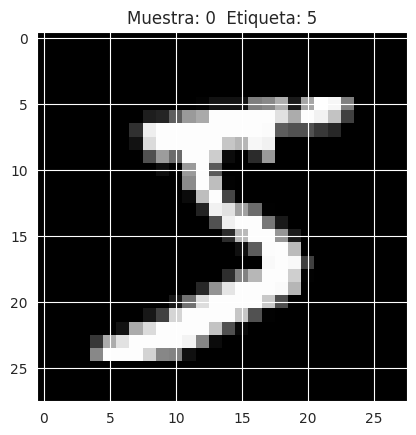

In [8]:
# Observar los digitos
view_digit(X_train, y_train, 0)

In [9]:
# Es necesario cambiar las etiquetas a una forma categorizada

def one_hot(series):
    label_binarizer = pp.LabelBinarizer()
    label_binarizer.fit(range(max(series)+1))
    return label_binarizer.transform(series)

def reverse_one_hot(originalSeries, newSeries):
    label_binarizer = pp.LabelBinarizer()
    label_binarizer.fit(range(max(originalSeries)+1))
    return label_binarizer.inverse_transform(newSeries)

# Uso de las funciones
y_train_oneHot = one_hot(y_train)
y_validation_oneHot = one_hot(y_val)
y_test_oneHot = one_hot(y_test)

In [10]:
# Mostrar las etiquetas ya procesadas
y_train_oneHot[0]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

# RBM como clase de python

In [11]:
# Define RBM class
class RBM(object):

    def __init__(self, input_size, output_size,
                 learning_rate, epochs, batchsize):
        # Define hyperparameters
        self._input_size = input_size
        self._output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batchsize = batchsize

        # Initialize weights and biases using zero matrices
        self.w = np.zeros([input_size, output_size], dtype=np.float32)
        self.hb = np.zeros([output_size], dtype=np.float32)
        self.vb = np.zeros([input_size], dtype=np.float32)

    def prob_h_given_v(self, visible, w, hb):
        return tf.nn.sigmoid(tf.matmul(visible, w) + hb)

    def prob_v_given_h(self, hidden, w, vb):
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(w)) + vb)

    def sample_prob(self, probs):
        return tf.nn.relu(tf.sign(probs - tf.random_uniform(tf.shape(probs))))

    def train(self, X):
        _w = tf.placeholder(tf.float32, [self._input_size, self._output_size])
        _hb = tf.placeholder(tf.float32, [self._output_size])
        _vb = tf.placeholder(tf.float32, [self._input_size])

        prv_w = np.zeros([self._input_size, self._output_size], dtype=np.float32)
        prv_hb = np.zeros([self._output_size], dtype=np.float32)
        prv_vb = np.zeros([self._input_size], dtype=np.float32)

        cur_w = np.zeros([self._input_size, self._output_size], dtype=np.float32)
        cur_hb = np.zeros([self._output_size], dtype=np.float32)
        cur_vb = np.zeros([self._input_size], dtype=np.float32)

        v0 = tf.placeholder(tf.float32, [None, self._input_size])
        h0 = self.sample_prob(self.prob_h_given_v(v0, _w, _hb))
        v1 = self.sample_prob(self.prob_v_given_h(h0, _w, _vb))
        h1 = self.prob_h_given_v(v1, _w, _hb)

        positive_grad = tf.matmul(tf.transpose(v0), h0)
        negative_grad = tf.matmul(tf.transpose(v1), h1)

        update_w = _w + self.learning_rate * \
            (positive_grad - negative_grad) / tf.to_float(tf.shape(v0)[0])
        update_vb = _vb +  self.learning_rate * tf.reduce_mean(v0 - v1, 0)
        update_hb = _hb +  self.learning_rate * tf.reduce_mean(h0 - h1, 0)

        err = tf.reduce_mean(tf.square(v0 - v1))

        error_list = []

        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())

            for epoch in range(self.epochs):
                for start, end in zip(range(0, len(X), \
                        self.batchsize),range(self.batchsize,len(X), \
                                              self.batchsize)):
                    batch = X[start:end]
                    cur_w = sess.run(update_w, feed_dict={v0: batch, \
                                    _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_hb = sess.run(update_hb, feed_dict={v0: batch, \
                                    _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_vb = sess.run(update_vb, feed_dict={v0: batch, \
                                    _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    prv_w = cur_w
                    prv_hb = cur_hb
                    prv_vb = cur_vb
                error = sess.run(err, feed_dict={v0: X, \
                                _w: cur_w, _vb: cur_vb, _hb: cur_hb})
                print ('Epoch: %d' % epoch,'reconstruction error: %f' % error)
                error_list.append(error)
            self.w = prv_w
            self.hb = prv_hb
            self.vb = prv_vb
            return error_list

    def rbm_output(self, X):

        input_X = tf.constant(X)
        _w = tf.constant(self.w)
        _hb = tf.constant(self.hb)
        _vb = tf.constant(self.vb)
        out = tf.nn.sigmoid(tf.matmul(input_X, _w) + _hb)
        hiddenGen = self.sample_prob(self.prob_h_given_v(input_X, _w, _hb))
        visibleGen = self.sample_prob(self.prob_v_given_h(hiddenGen, _w, _vb))
        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())
            return sess.run(out), sess.run(visibleGen), sess.run(hiddenGen)

    def show_features(self, shape, suptitle, count=-1):
        maxw = np.amax(self.w.T)
        minw = np.amin(self.w.T)
        count = self._output_size if count == -1 or count > \
                self._output_size else count
        ncols = count if count < 14 else 14
        nrows = count//ncols
        nrows = nrows if nrows > 2 else 3
        fig = plt.figure(figsize=(ncols, nrows), dpi=100)
        grid = Grid(fig, rect=111, nrows_ncols=(nrows, ncols), axes_pad=0.01)

        for i, ax in enumerate(grid):
            x = self.w.T[i] if i<self._input_size else np.zeros(shape)
            x = (x.reshape(1, -1) - minw)/maxw
            ax.imshow(x.reshape(*shape), cmap=mpl.cm.Greys)
            ax.set_axis_off()

        fig.text(0.5,1, suptitle, fontsize=20, horizontalalignment='center')
        fig.tight_layout()
        plt.show()
        return

# Entrenamiento del modelo

In [12]:
# Para el entrenamiento se procesan los datos
inputX = np.array(X_train)
inputX = inputX.astype(np.float32)

# Crear una lista que contendra los RBMs
rbm_list = []

# Se definen los parametros para entrenar
rbm_list.append(RBM(784,700,1.0,100,200))
rbm_list.append(RBM(700,600,1.0,100,200))
rbm_list.append(RBM(600,500,1.0,100,200))

In [13]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [14]:
outputList = []
error_list = []
# Para cada RBM se procesa:
for i in range(0,len(rbm_list)):
    print('RBM', i+1)
    # Entrenar una nueva
    rbm = rbm_list[i]
    err = rbm.train(inputX)
    error_list.append(err)
    # Regresa la output layer
    outputX, reconstructedX, hiddenX = rbm.rbm_output(inputX)
    outputList.append(outputX)
    inputX = hiddenX

RBM 1
Instructions for updating:
Use `tf.cast` instead.


I0000 00:00:1739152142.356470   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1739152142.367425   12132 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


Epoch: 0 reconstruction error: 0.074478
Epoch: 1 reconstruction error: 0.064886
Epoch: 2 reconstruction error: 0.059871
Epoch: 3 reconstruction error: 0.055731
Epoch: 4 reconstruction error: 0.052867
Epoch: 5 reconstruction error: 0.050802
Epoch: 6 reconstruction error: 0.048987
Epoch: 7 reconstruction error: 0.047639
Epoch: 8 reconstruction error: 0.046437
Epoch: 9 reconstruction error: 0.045843
Epoch: 10 reconstruction error: 0.045208
Epoch: 11 reconstruction error: 0.044274
Epoch: 12 reconstruction error: 0.044355
Epoch: 13 reconstruction error: 0.043613
Epoch: 14 reconstruction error: 0.043276
Epoch: 15 reconstruction error: 0.043180
Epoch: 16 reconstruction error: 0.042871
Epoch: 17 reconstruction error: 0.042439
Epoch: 18 reconstruction error: 0.042691
Epoch: 19 reconstruction error: 0.042275
Epoch: 20 reconstruction error: 0.042112
Epoch: 21 reconstruction error: 0.041978
Epoch: 22 reconstruction error: 0.041465
Epoch: 23 reconstruction error: 0.041859
Epoch: 24 reconstruction e

I0000 00:00:1739152318.058895   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


RBM 2


...

I0000 00:00:1739152467.995142   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


RBM 3


I0000 00:00:1739152475.117050   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch: 0 reconstruction error: 0.038975
Epoch: 1 reconstruction error: 0.033438
Epoch: 2 reconstruction error: 0.030438
Epoch: 3 reconstruction error: 0.028634
Epoch: 4 reconstruction error: 0.027281
Epoch: 5 reconstruction error: 0.026138
Epoch: 6 reconstruction error: 0.025642
Epoch: 7 reconstruction error: 0.024795
Epoch: 8 reconstruction error: 0.024157
Epoch: 9 reconstruction error: 0.023680
Epoch: 10 reconstruction error: 0.023405
Epoch: 11 reconstruction error: 0.023139
Epoch: 12 reconstruction error: 0.022571
Epoch: 13 reconstruction error: 0.022336
Epoch: 14 reconstruction error: 0.021966
Epoch: 15 reconstruction error: 0.021828
Epoch: 16 reconstruction error: 0.021610
Epoch: 17 reconstruction error: 0.021257
Epoch: 18 reconstruction error: 0.021139
Epoch: 19 reconstruction error: 0.020867
Epoch: 20 reconstruction error: 0.020610
Epoch: 21 reconstruction error: 0.020554
Epoch: 22 reconstruction error: 0.020546
Epoch: 23 reconstruction error: 0.020213
Epoch: 24 reconstruction e

I0000 00:00:1739152619.354527   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


RBM 1


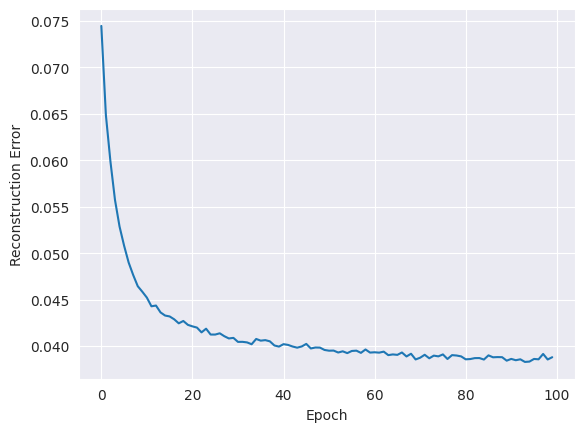

RBM 2


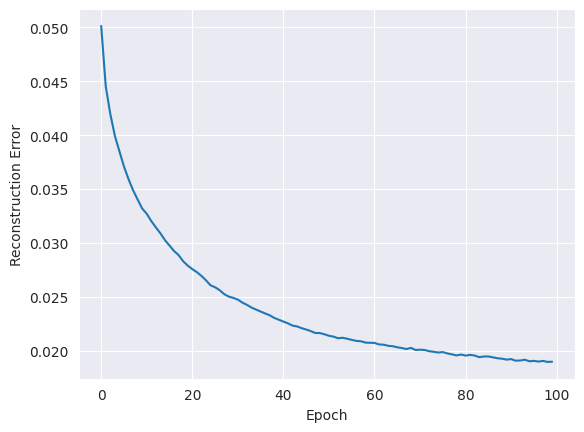

RBM 3


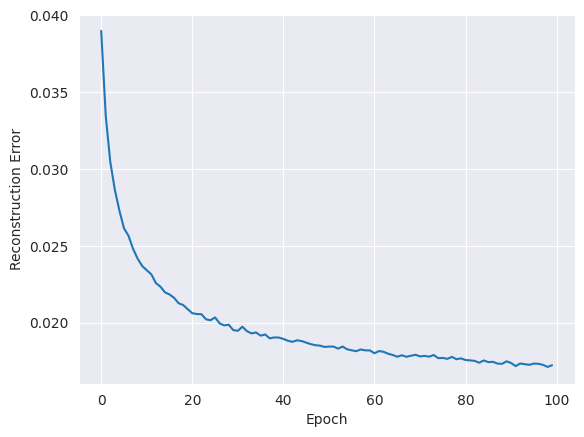

In [15]:
# Graficar reconstruction errors
i = 1
for err in error_list:
    print("RBM",i)
    pd.Series(err).plot(logy=False)
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction Error")
    plt.show()
    i += 1

RBM 0


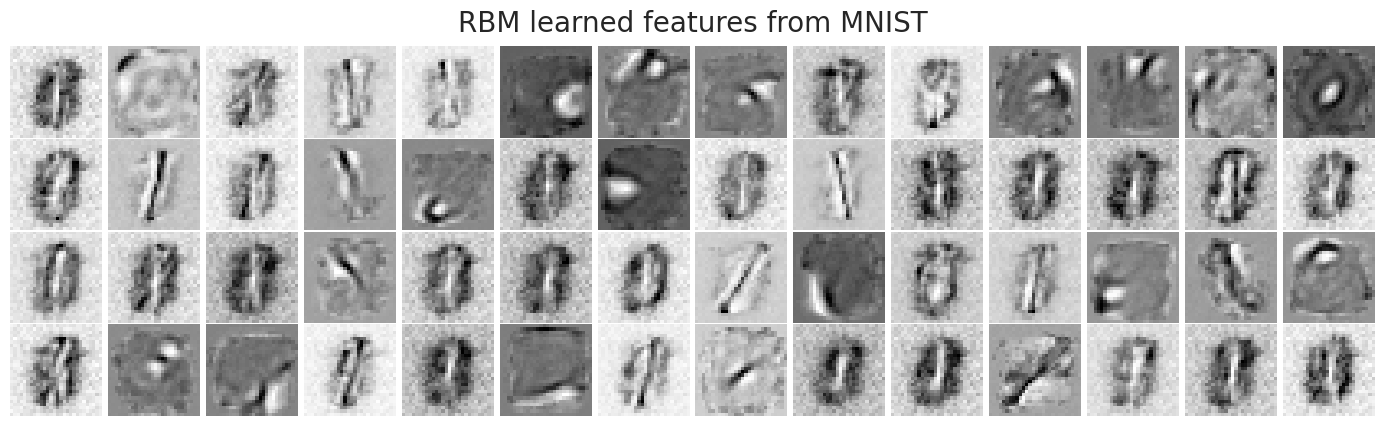

None
RBM 1


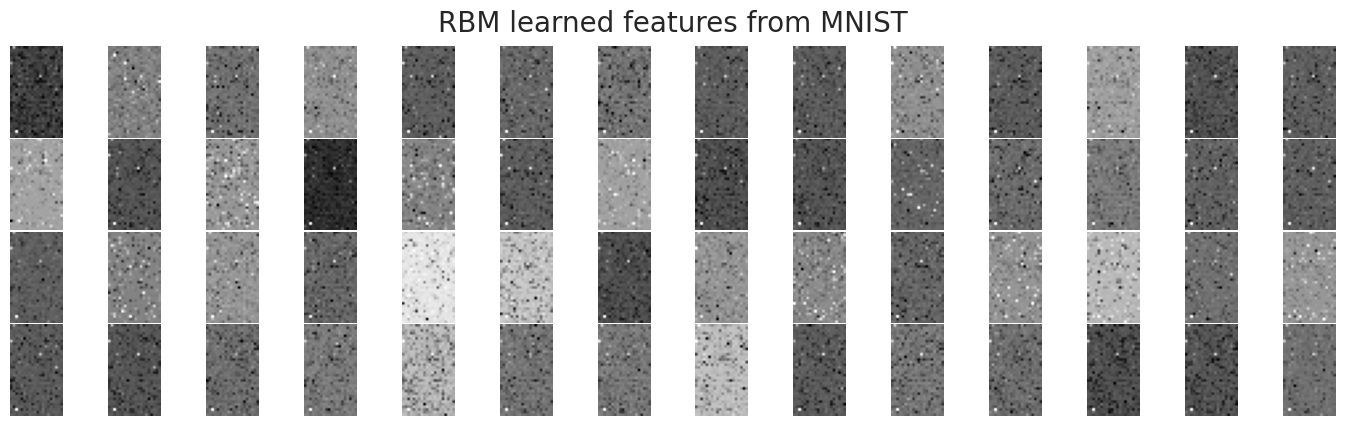

None
RBM 2


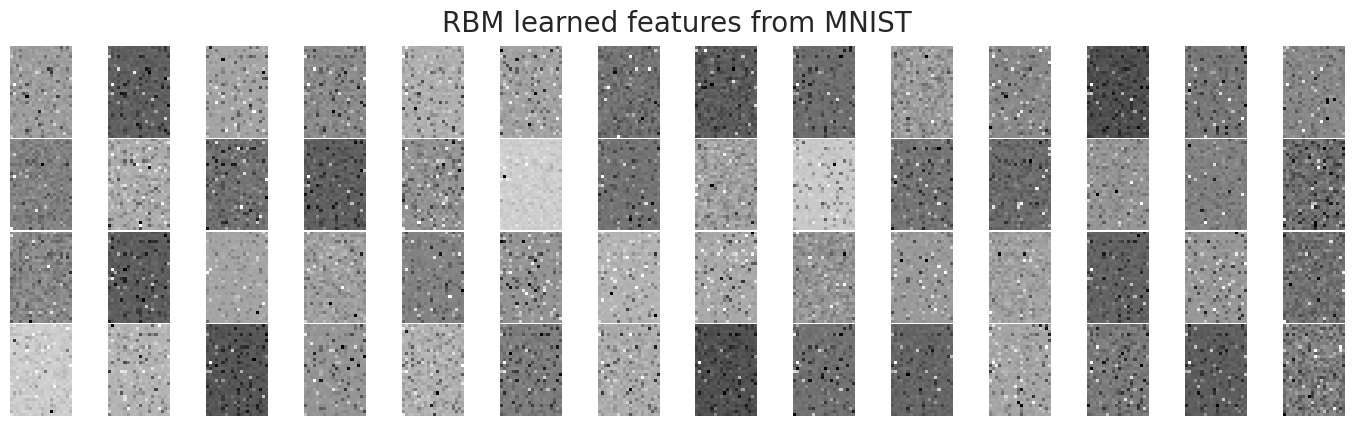

None


In [16]:
# Examine Feature Detectors
rbm_shapes = [(28,28),(35,20),(30,20)]
for i in range(0,len(rbm_list)):
    rbm = rbm_list[i]
    print("RBM",i)
    print(rbm.show_features(rbm_shapes[i], \
                            "RBM learned features from MNIST", 56))

RBM 1


I0000 00:00:1739152635.736818   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Image generated by RBM


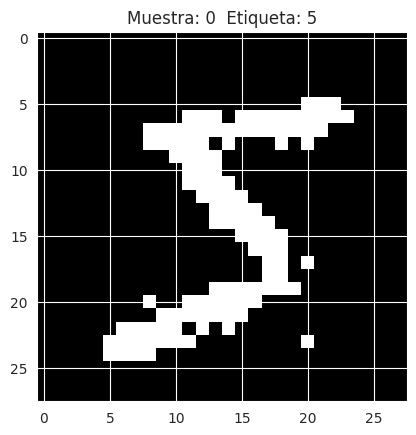

Original image


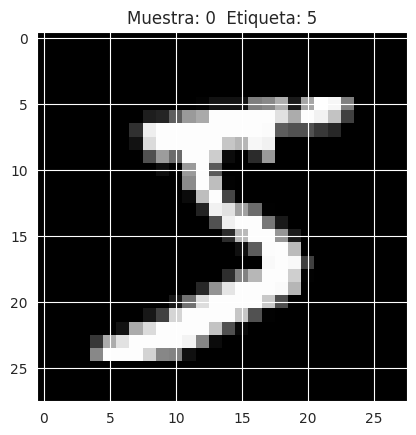

Image generated by RBM


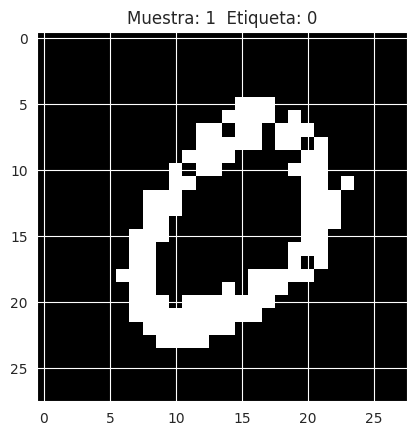

Original image


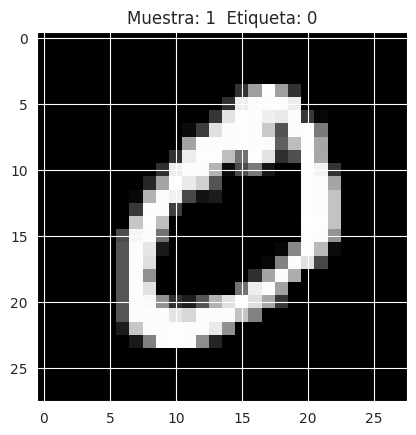

Image generated by RBM


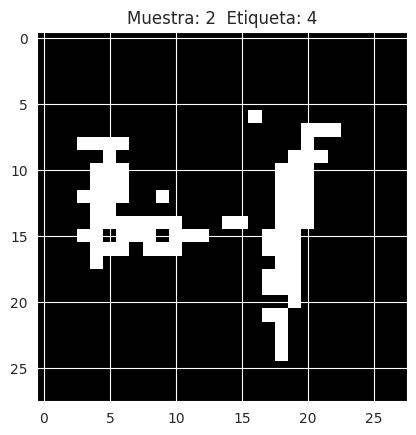

Original image


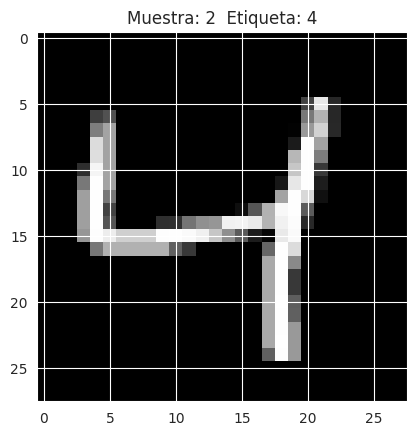

Image generated by RBM


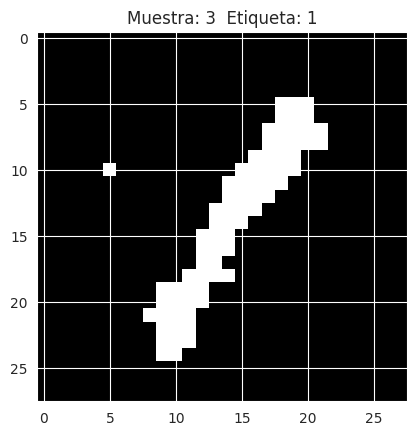

Original image


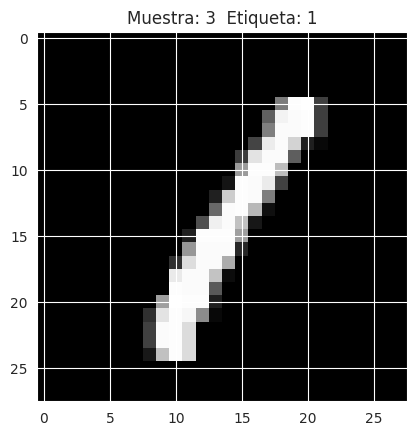

Image generated by RBM


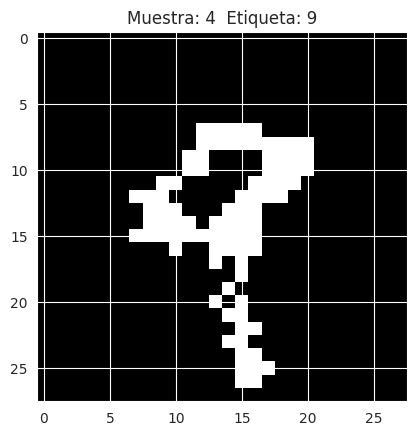

Original image


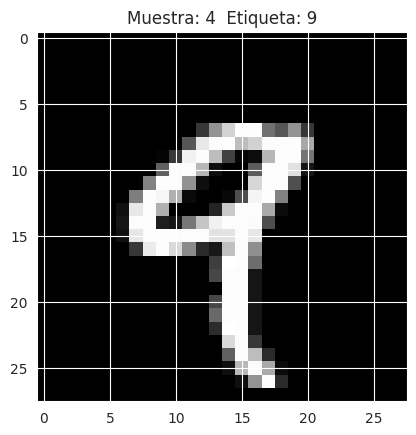

Image generated by RBM


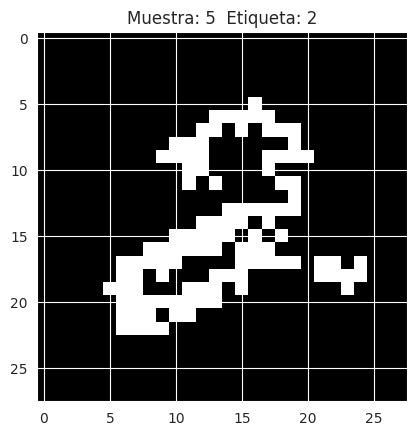

Original image


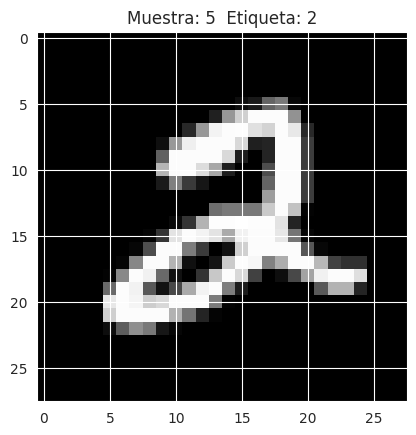

Image generated by RBM


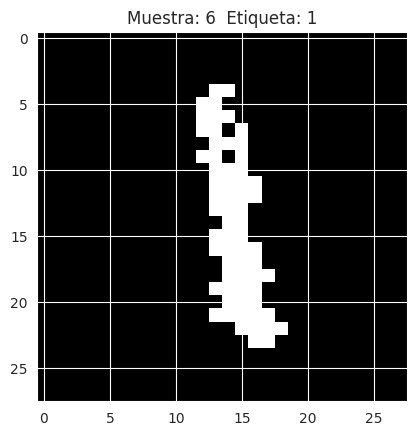

Original image


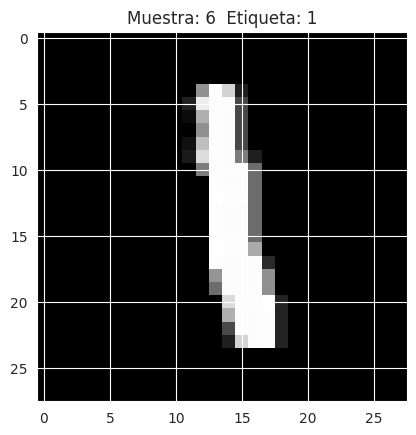

Image generated by RBM


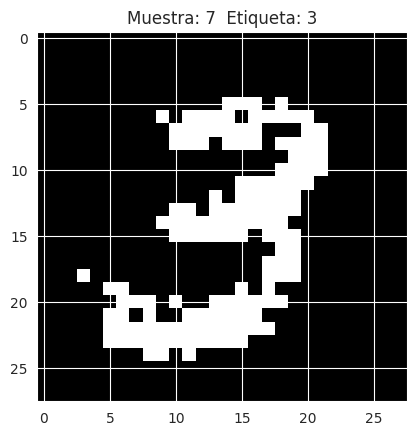

Original image


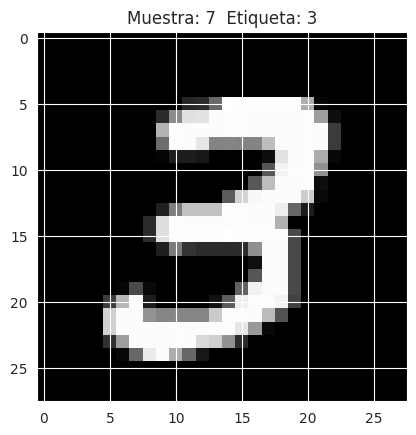

Image generated by RBM


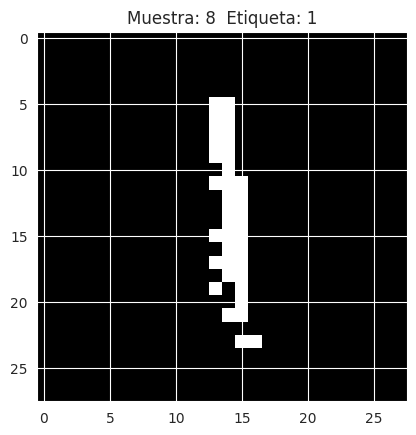

Original image


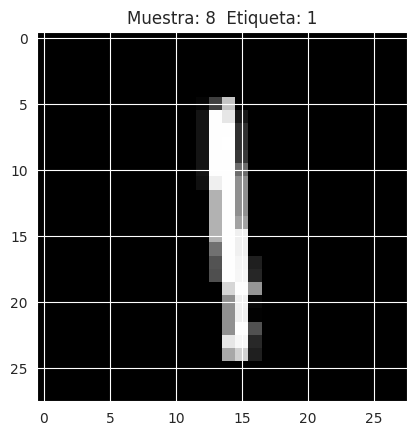

Image generated by RBM


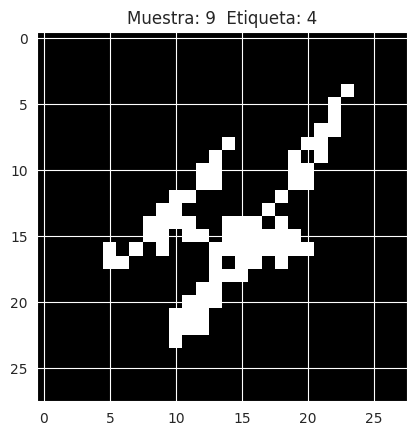

Original image


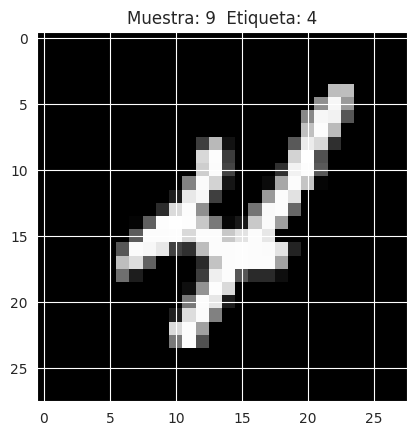

In [17]:
# Observar las imagenes generadas por la primera RBM
inputX = np.array(X_train).astype(np.float32)
rbmOne = rbm_list[0]

print('RBM 1')
outputX_rbmOne, reconstructedX_rbmOne, hiddenX_rbmOne =  rbmOne.rbm_output(inputX)
reconstructedX_rbmOne = pd.DataFrame(data=reconstructedX_rbmOne,  index=X_train.index)
for j in range(0,10):
    example = j
    print("Image generated by RBM")
    view_digit(reconstructedX_rbmOne, y_train, example)
    print("Original image")
    view_digit(X_train, y_train, example)

# Probar el modelo con DBN

## Clase DBN

In [18]:
class DBN(object):
    def __init__(self, original_input_size, input_size, output_size,
                 learning_rate, epochs, batchsize, rbmOne, rbmTwo, rbmThree):
        # Define hyperparameters
        self._original_input_size = original_input_size
        self._input_size = input_size
        self._output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batchsize = batchsize
        self.rbmOne = rbmOne
        self.rbmTwo = rbmTwo
        self.rbmThree = rbmThree

        self.w = np.zeros([input_size, output_size], "float")
        self.hb = np.zeros([output_size], "float")
        self.vb = np.zeros([input_size], "float")

    def prob_h_given_v(self, visible, w, hb):
        return tf.nn.sigmoid(tf.matmul(visible, w) + hb)

    def prob_v_given_h(self, hidden, w, vb):
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(w)) + vb)

    def sample_prob(self, probs):
        return tf.nn.relu(tf.sign(probs - tf.random_uniform(tf.shape(probs))))

    def train(self, X):
        _w = tf.placeholder("float", [self._input_size, self._output_size])
        _hb = tf.placeholder("float", [self._output_size])
        _vb = tf.placeholder("float", [self._input_size])

        prv_w = np.zeros([self._input_size, self._output_size], "float")
        prv_hb = np.zeros([self._output_size], "float")
        prv_vb = np.zeros([self._input_size], "float")

        cur_w = np.zeros([self._input_size, self._output_size], "float")
        cur_hb = np.zeros([self._output_size], "float")
        cur_vb = np.zeros([self._input_size], "float")

        v0 = tf.placeholder("float", [None, self._original_input_size])

        forwardOne = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(v0, \
                        self.rbmOne.w) + self.rbmOne.hb) - tf.random_uniform( \
                        tf.shape(tf.nn.sigmoid(tf.matmul(v0, self.rbmOne.w) + \
                        self.rbmOne.hb)))))
        forwardTwo = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(forwardOne, \
                        self.rbmTwo.w) + self.rbmTwo.hb) - tf.random_uniform( \
                        tf.shape(tf.nn.sigmoid(tf.matmul(forwardOne, \
                        self.rbmTwo.w) + self.rbmTwo.hb)))))
        forward = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(forwardTwo, \
                        self.rbmThree.w) + self.rbmThree.hb) - \
                        tf.random_uniform(tf.shape(tf.nn.sigmoid(tf.matmul( \
                        forwardTwo, self.rbmThree.w) + self.rbmThree.hb)))))
        h0 = self.sample_prob(self.prob_h_given_v(forward, _w, _hb))
        v1 = self.sample_prob(self.prob_v_given_h(h0, _w, _vb))
        h1 = self.prob_h_given_v(v1, _w, _hb)

        positive_grad = tf.matmul(tf.transpose(forward), h0)
        negative_grad = tf.matmul(tf.transpose(v1), h1)

        update_w = _w + self.learning_rate * (positive_grad - negative_grad) / \
                        tf.to_float(tf.shape(forward)[0])
        update_vb = _vb +  self.learning_rate * tf.reduce_mean(forward - v1, 0)
        update_hb = _hb +  self.learning_rate * tf.reduce_mean(h0 - h1, 0)

        backwardOne = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(v1, \
                            self.rbmThree.w.T) + self.rbmThree.vb) - \
                            tf.random_uniform(tf.shape(tf.nn.sigmoid( \
                            tf.matmul(v1, self.rbmThree.w.T) + \
                            self.rbmThree.vb)))))
        backwardTwo = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(backwardOne, \
                            self.rbmTwo.w.T) + self.rbmTwo.vb) - \
                            tf.random_uniform(tf.shape(tf.nn.sigmoid( \
                            tf.matmul(backwardOne, self.rbmTwo.w.T) + \
                            self.rbmTwo.vb)))))
        backward = tf.nn.relu(tf.sign(tf.nn.sigmoid(tf.matmul(backwardTwo, \
                            self.rbmOne.w.T) + self.rbmOne.vb) - \
                            tf.random_uniform(tf.shape(tf.nn.sigmoid( \
                            tf.matmul(backwardTwo, self.rbmOne.w.T) + \
                            self.rbmOne.vb)))))

        err = tf.reduce_mean(tf.square(v0 - backward))
        error_list = []

        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())

            for epoch in range(self.epochs):
                for start, end in zip(range(0, len(X), self.batchsize), \
                        range(self.batchsize,len(X), self.batchsize)):
                    batch = X[start:end]
                    cur_w = sess.run(update_w, feed_dict={v0: batch, _w: \
                                        prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_hb = sess.run(update_hb, feed_dict={v0: batch, _w: \
                                        prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_vb = sess.run(update_vb, feed_dict={v0: batch, _w: \
                                        prv_w, _hb: prv_hb, _vb: prv_vb})
                    prv_w = cur_w
                    prv_hb = cur_hb
                    prv_vb = cur_vb
                error = sess.run(err, feed_dict={v0: X, _w: cur_w, _vb: \
                                    cur_vb, _hb: cur_hb})
                print ('Epoch: %d' % epoch,'reconstruction error: %f' % error)
                error_list.append(error)
            self.w = prv_w
            self.hb = prv_hb
            self.vb = prv_vb
            return error_list

    def dbn_output(self, X):

        input_X = tf.constant(X)
        forwardOne = tf.nn.sigmoid(tf.matmul(input_X, self.rbmOne.w) + \
                                   self.rbmOne.hb)
        forwardTwo = tf.nn.sigmoid(tf.matmul(forwardOne, self.rbmTwo.w) + \
                                   self.rbmTwo.hb)
        forward = tf.nn.sigmoid(tf.matmul(forwardTwo, self.rbmThree.w) + \
                                self.rbmThree.hb)

        _w = tf.constant(self.w)
        _hb = tf.constant(self.hb)
        _vb = tf.constant(self.vb)

        out = tf.nn.sigmoid(tf.matmul(forward, _w) + _hb)
        hiddenGen = self.sample_prob(self.prob_h_given_v(forward, _w, _hb))
        visibleGen = self.sample_prob(self.prob_v_given_h(hiddenGen, _w, _vb))

        backwardTwo = tf.nn.sigmoid(tf.matmul(visibleGen, self.rbmThree.w.T) + \
                                    self.rbmThree.vb)
        backwardOne = tf.nn.sigmoid(tf.matmul(backwardTwo, self.rbmTwo.w.T) + \
                                    self.rbmTwo.vb)
        backward = tf.nn.sigmoid(tf.matmul(backwardOne, self.rbmOne.w.T) + \
                                 self.rbmOne.vb)

        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())
            return sess.run(out), sess.run(backward)

    def show_features(self, shape, suptitle, count=-1):
        maxw = np.amax(self.w.T)
        minw = np.amin(self.w.T)
        count = self._output_size if count == -1 or count > \
                self._output_size else count
        ncols = count if count < 14 else 14
        nrows = count//ncols
        nrows = nrows if nrows > 2 else 3
        fig = plt.figure(figsize=(ncols, nrows), dpi=100)
        grid = Grid(fig, rect=111, nrows_ncols=(nrows, ncols), axes_pad=0.01)

        for i, ax in enumerate(grid):
            x = self.w.T[i] if i<self._input_size else np.zeros(shape)
            x = (x.reshape(1, -1) - minw)/maxw
            ax.imshow(x.reshape(*shape), cmap=mpl.cm.Greys)
            ax.set_axis_off()

        fig.text(0.5,1, suptitle, fontsize=20, horizontalalignment='center')
        fig.tight_layout()
        plt.show()
        return

## Entrenamiento

In [19]:
# Instantiate DBN Class
dbn = DBN(784, 500, 500, 1.0, 50, 200, rbm_list[0], rbm_list[1], rbm_list[2])

In [20]:
inputX = np.array(X_train)
error_list = []
error_list = dbn.train(inputX)

I0000 00:00:1739152751.885526   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch: 0 reconstruction error: 0.087980
Epoch: 1 reconstruction error: 0.080020
Epoch: 2 reconstruction error: 0.076581
Epoch: 3 reconstruction error: 0.074344
Epoch: 4 reconstruction error: 0.072658
Epoch: 5 reconstruction error: 0.071450
Epoch: 6 reconstruction error: 0.070395
Epoch: 7 reconstruction error: 0.069568
Epoch: 8 reconstruction error: 0.068856
Epoch: 9 reconstruction error: 0.068339
Epoch: 10 reconstruction error: 0.067655
Epoch: 11 reconstruction error: 0.067370
Epoch: 12 reconstruction error: 0.066956
Epoch: 13 reconstruction error: 0.066650
Epoch: 14 reconstruction error: 0.066428
Epoch: 15 reconstruction error: 0.066090
Epoch: 16 reconstruction error: 0.065883
Epoch: 17 reconstruction error: 0.065470
Epoch: 18 reconstruction error: 0.065090
Epoch: 19 reconstruction error: 0.064959
Epoch: 20 reconstruction error: 0.064682
Epoch: 21 reconstruction error: 0.064471
Epoch: 22 reconstruction error: 0.064408
Epoch: 23 reconstruction error: 0.064095
Epoch: 24 reconstruction e

DBN


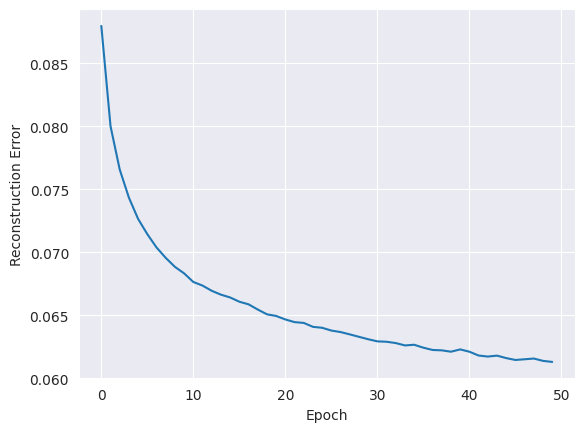

In [21]:
# Grafica reconstruction errors
print("DBN")
pd.Series(error_list).plot(logy=False)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error")
plt.show()

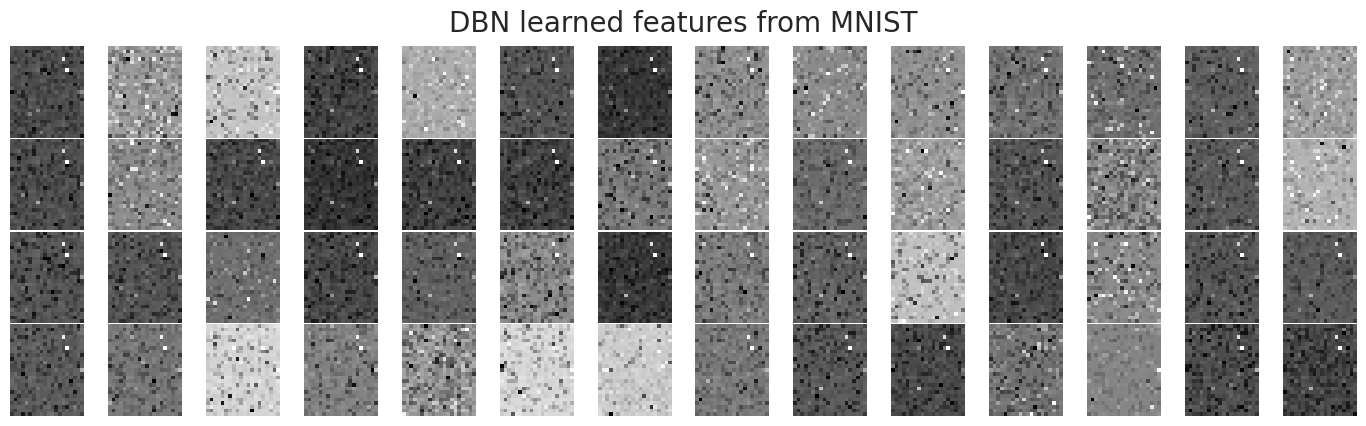

None


In [22]:
print(dbn.show_features((25,20),"DBN learned features from MNIST", 56))

In [23]:
# Generate images and store them
inputXReduced = X_train.loc[:4999].astype('float32')
for i in range(0,20):
    print("Run ",i)
    finalOutput_DBN, reconstructedOutput_DBN = dbn.dbn_output(inputXReduced)
    if i==0:
        generatedImages = finalOutput_DBN
    else:
        generatedImages = np.append(generatedImages, finalOutput_DBN, axis=0)

Run  0


I0000 00:00:1739152890.945451   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Run  1


I0000 00:00:1739152894.308912   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Run  2


...

I0000 00:00:1739152938.236297   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Run  18


I0000 00:00:1739152941.380571   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Run  19


I0000 00:00:1739152944.817653   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [24]:
# Generate a vector of labels for the generated images
for i in range(0,20):
    if i==0:
        labels = y_train.loc[:4999]
    else:
        labels = np.append(labels,y_train.loc[:4999])

In [25]:
# Generate images based on the validation set
inputValidation = np.array(X_val).astype('float32')
finalOutput_DBN_validation, reconstructedOutput_DBN_validation = dbn.dbn_output(inputValidation)

I0000 00:00:1739153012.577792   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


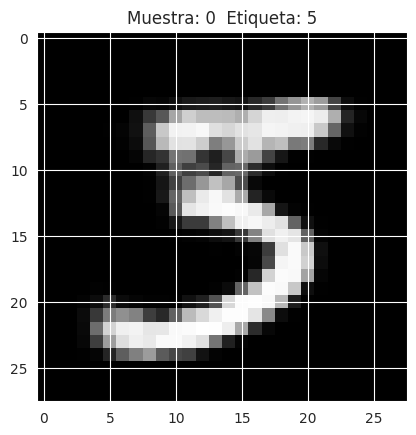

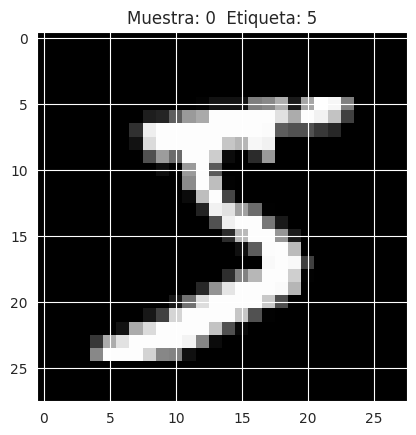

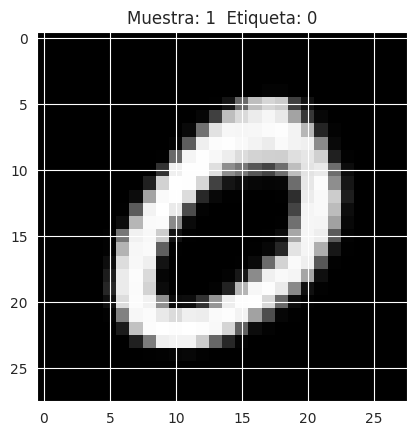

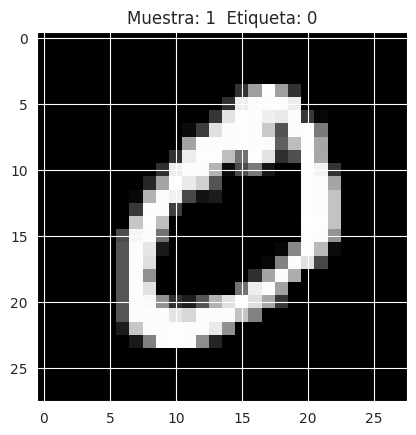

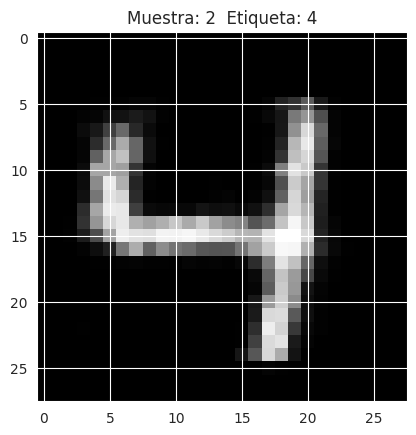

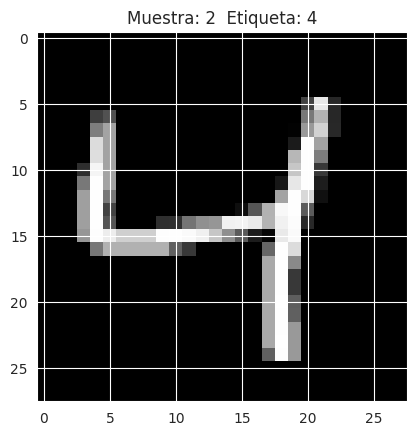

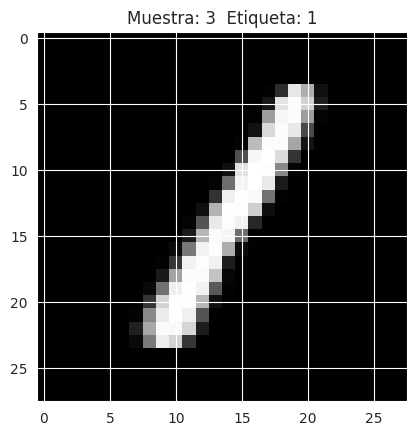

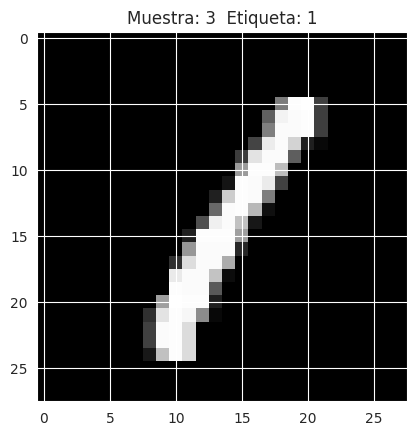

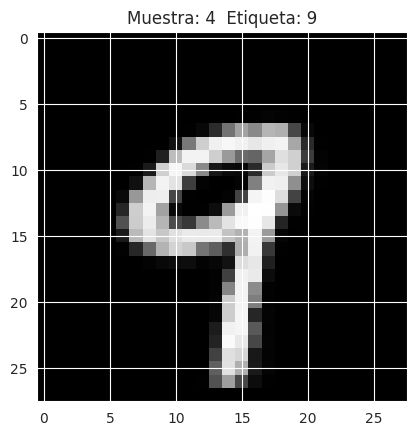

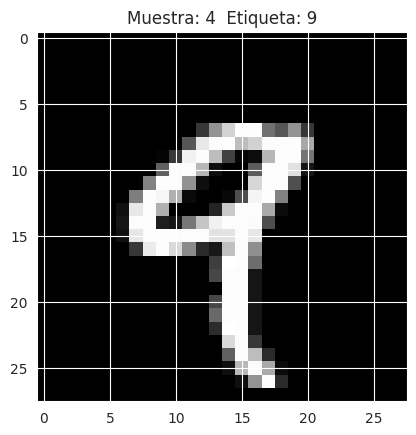

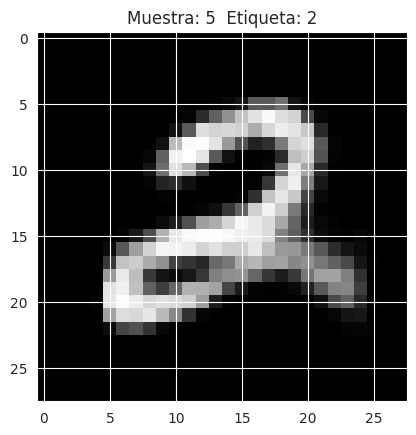

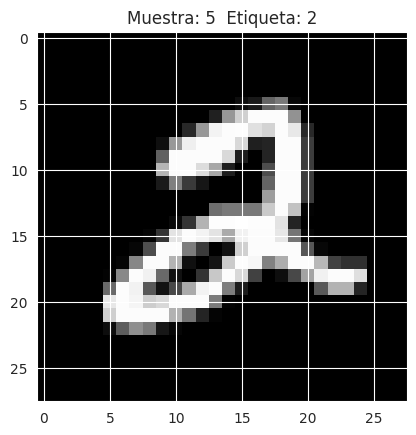

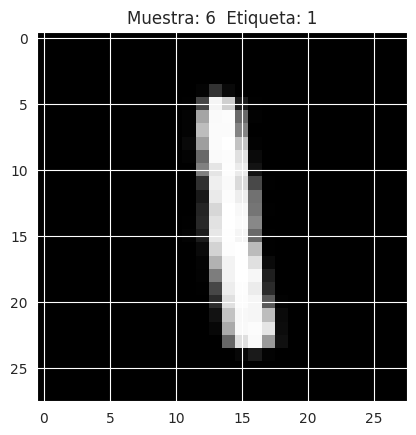

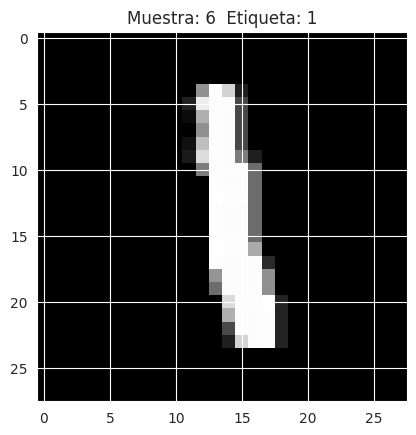

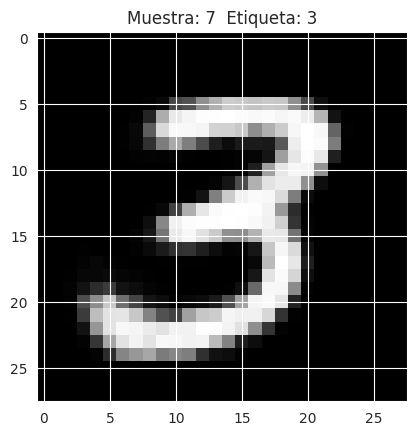

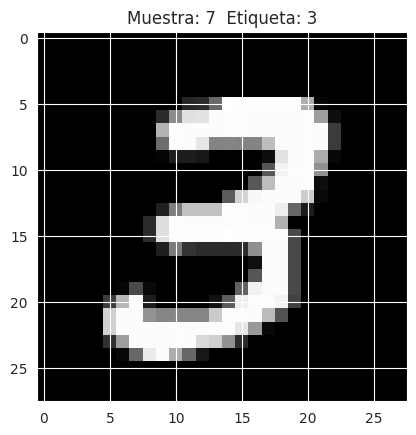

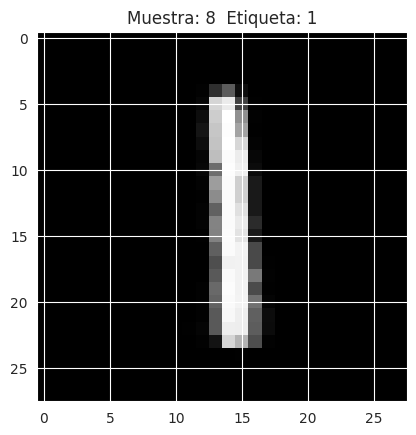

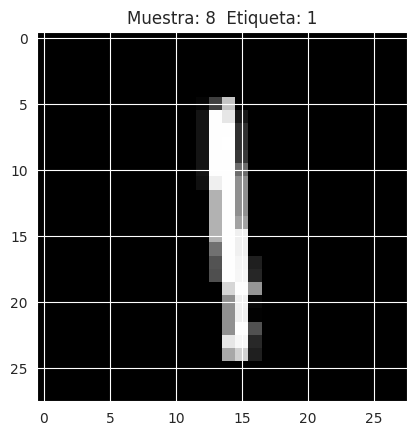

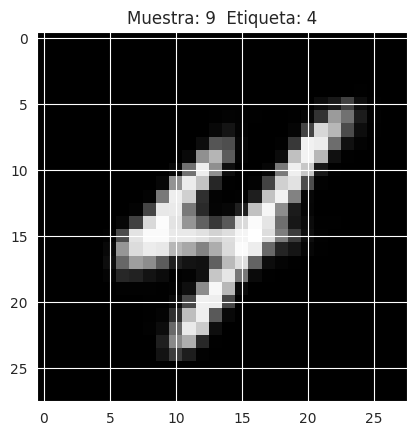

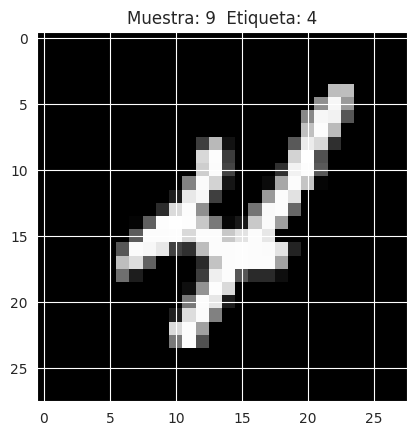

In [26]:
# View first few reconstructed images
for i in range(0,10):
    example = i
    reconstructedX = pd.DataFrame(data=reconstructedOutput_DBN, \
                                  index=X_train[0:5000].index)
    view_digit(reconstructedX, y_train, example)
    view_digit(X_train, y_train, example)

Run  0


I0000 00:00:1739153046.300428   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


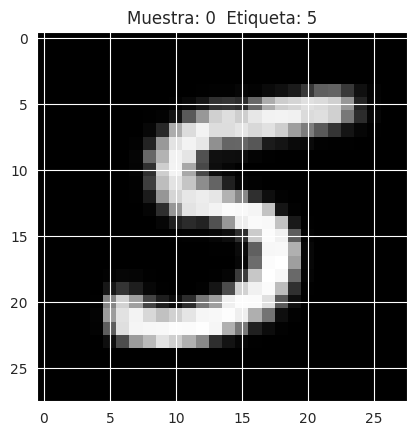

Run  1


I0000 00:00:1739153051.341812   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


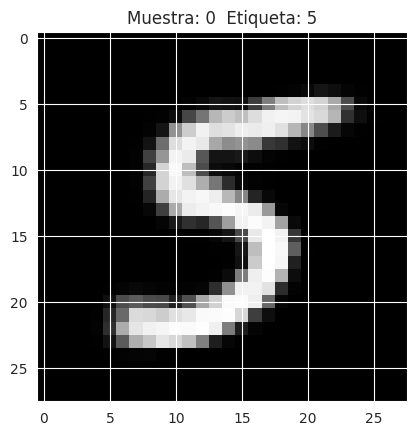

Run  2


I0000 00:00:1739153054.831104   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


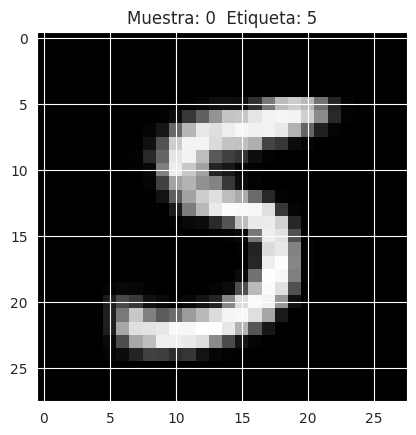

Run  3


I0000 00:00:1739153057.924547   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


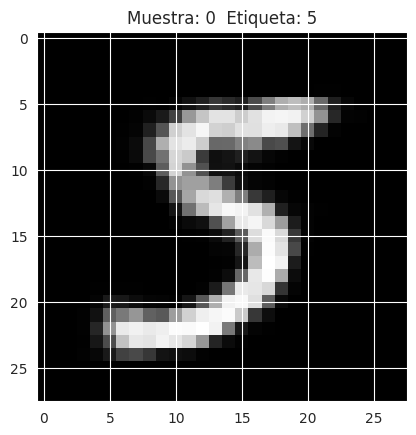

Run  4


I0000 00:00:1739153061.245572   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


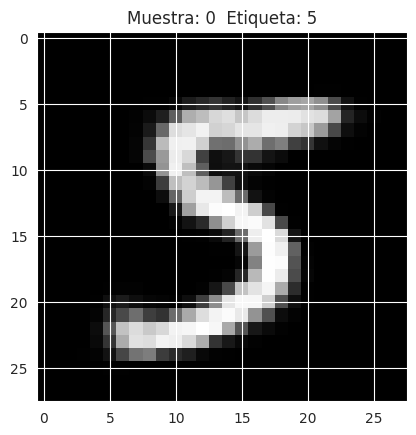

Run  5


I0000 00:00:1739153064.994132   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


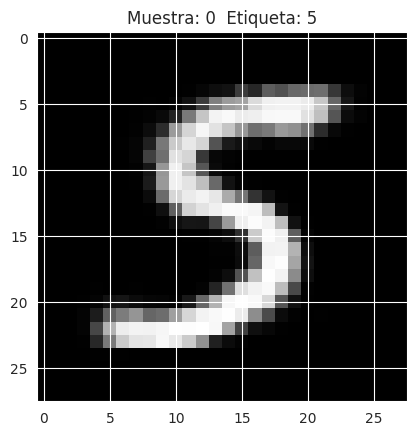

Run  6


I0000 00:00:1739153068.837500   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


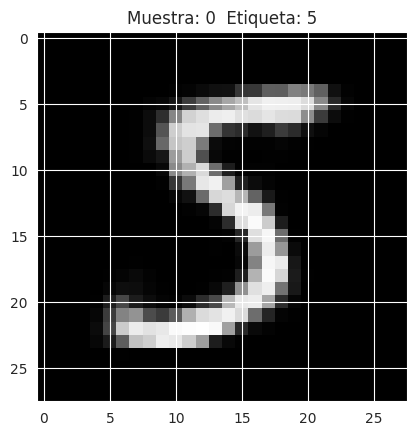

Run  7


I0000 00:00:1739153072.357425   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


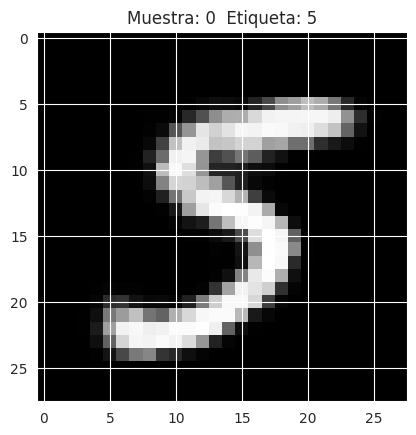

Run  8


I0000 00:00:1739153076.741817   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


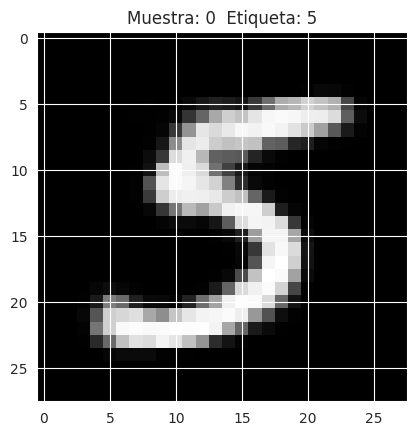

Run  9


I0000 00:00:1739153081.609091   12132 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Generated


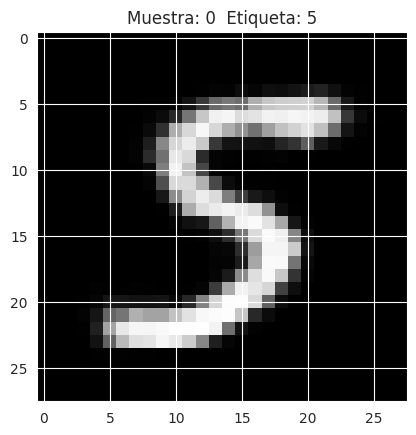

In [27]:
# Generate the first examp times
inputXReduced = X_train.loc[:0].astype('float32')
for i in range(0,10):
    example = 0
    print("Run ",i)
    finalOutput_DBN_fives, reconstructedOutput_DBN_fives =  dbn.dbn_output(inputXReduced)
    reconstructedX_fives = pd.DataFrame(data=reconstructedOutput_DBN_fives, index=[0])
    print("Generated")
    view_digit(reconstructedX_fives, y_train.loc[:0], example)